<a href="https://colab.research.google.com/github/DarioPacoGuisado/Entrega-GPs./blob/main/GPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar GPs

DARÍO PACO GUISADO.

El objetivo es aprender a simular trayectorias de un GP, usando algunas de las herramientas más habituales de _machine learning_ (las que hemos visto: Python, Numpy, matplotlib). Como resultado final, generaremos las imágenes vistas en las diapositivas.

**Nota:** Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Igual que con el PAS, tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

In [1]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$

Para ello, utiliza la función `np.random.multivariate_normal` (busca en internet cómo usarla).

Además, visualiza el resultado obtenido, así como su shape.

In [2]:
#La media es 0, la covarianza es la identidad. Y el número de samples es 50.
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[-0.95764881  0.23209802  0.61090063]
 [-1.09650902  1.93961266 -1.54772693]
 [-0.28619886  1.09673283  0.0039522 ]
 [-0.17899169  2.46033171  0.80656359]
 [ 1.41686976 -0.26962214  1.05186105]
 [ 0.1307896  -0.34892626  0.17646114]
 [ 0.50152625  1.58890064 -1.50492128]
 [-0.11762313  0.35147387  0.11051581]
 [-0.983682   -0.22956927 -1.13898938]
 [-1.46051927 -0.48549657  1.1639701 ]
 [-3.06763114 -0.73257221  1.4597951 ]
 [ 1.55836    -0.23708946 -0.27015266]
 [ 0.21281304  1.41100784 -0.30198264]
 [-0.61546896 -0.66497742  1.59948088]
 [ 0.95917308 -0.27023926 -0.52099436]
 [-0.14429099 -0.73835546 -0.98181887]
 [-0.23071384 -0.22818102  1.33274805]
 [ 1.27017131  1.48465578 -1.62729351]
 [-0.12799205 -0.25071626 -1.21380682]
 [ 0.09922589 -1.13334582 -0.47842112]
 [-1.18204296 -0.37755467  0.22276656]
 [ 1.28304484  0.00459239  0.0621649 ]
 [ 0.15752733  0.31539437  0.12444893]
 [ 0.35693235 -1.77150159 -0.6782971 ]
 [-0.37389221 -1.44004233 -0.84451346

Haz ahora lo mismo pero para una normal con matriz de covarianzas que no sea la identidad, sino por ejemplo $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

Puedes simplificar algo el código si usas la función `np.diag`.

¿Qué diferencias esperarías ver en las muestras obtenidas?

- La tercera componente debe tener más varianza que las dos primeras.

In [3]:
#La media es 0, la covarianza es diagonal. Y el número de samples es 50.
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag((1,10,100))
num_samples = 50
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 5.89402916e-02 -7.47815037e-01 -1.09230132e+01]
 [ 6.51850455e-01  1.30276752e+00  5.61737895e+00]
 [-7.58860873e-01 -3.29150618e+00  6.34593236e+00]
 [ 2.54523128e+00 -6.00623672e+00  6.57324859e+00]
 [ 6.80139422e-02  1.91903581e+00 -2.38733277e+01]
 [-8.33146871e-01  2.12097842e+00 -1.11861295e+00]
 [ 1.37594423e+00  5.39921857e+00 -1.08893234e+01]
 [-9.72788722e-01  3.37936448e+00  1.39314223e+00]
 [-4.48812858e-01 -8.14281552e-01 -1.40000257e+01]
 [ 1.27992169e+00  1.69916030e+00  4.48074188e+00]
 [-8.91840263e-01 -3.01622592e+00  9.37121548e+00]
 [-9.27833175e-02 -3.91486568e-01 -1.28686407e+01]
 [-4.51544962e-01  4.59246939e+00 -2.68311491e+00]
 [ 1.71393607e+00 -2.02901955e+00 -3.69144877e+00]
 [ 5.64453257e-01  1.71256119e-02  8.52130636e+00]
 [-1.29682186e-01  1.85065307e+00 -1.41613876e+01]
 [-6.12638019e-01  3.96497465e+00 -7.27857485e+00]
 [-1.65132636e-01 -6.77493332e-01 -1.62151014e+01]
 [-1.47629180e+00 -5.95243029e+00 -7.01434879e+00]
 [-1

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

En el punto 5 se explicará la manera más limpia de usar otras funciones de medias. También se comentará la manera más adecuada para pasar el kernel como argumento de la función. Es decir, de modo que no sea necesario definir `simular_GP_RBF`, sino simplemente `simular_GP` (y que el kernel se pase como argumento de la función). Todo ello necesita del concepto de _clases_, algo que (creo) no se estudia en el grado en matemáticas.

Definimos la función principal:

In [4]:

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
    """
    Simular un GP con kernel RBF.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t
    n = len(t)
    # Paso 1: calcula el vector de medias (que es cero por definición.)
    vector_medias = np.zeros(n)
    #Paso 2: Calcula el vector de covarianzas, que es el kernel RBF.
    #(t[:, None] - t[None, :]) genera la matriz $a_{ij} = t_i - t_j$
    matriz_covs = sigma_sq * np.exp(-1/2 * ((t[:, None] - t[None, :])/lengthscale)**2)

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

Ahora utilizamos esta función para generar imágenes similares a las de las diapositivas 59 y 62.

Para ello, genera las trayectorias con la función recién definida, `simular_GP_RBF`, y píntalas con `plt.plot`

Opcional: si quieres tener diferentes ejes (subplots) en la misma figura, como se hace en las diapositivas 59 y 62, puedes mirar cómo usar `plt.subplots`.

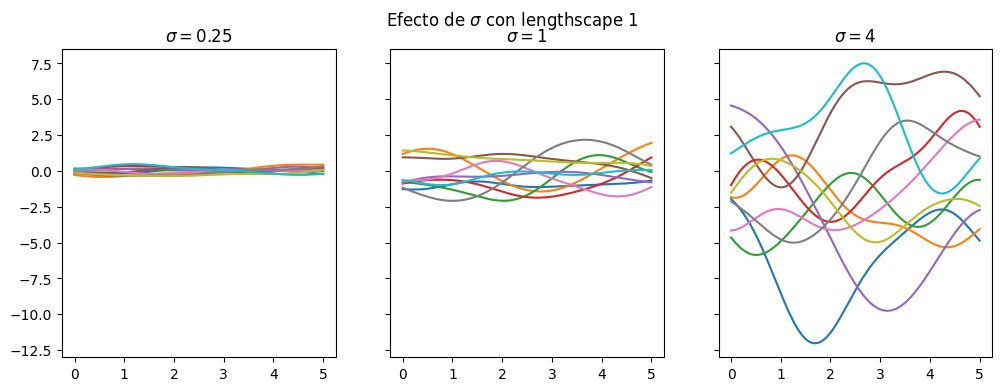

In [23]:
# DIAPOSITIVA 59
x = np.linspace(0,5,1000)
p_1 = simular_GP_RBF(x,1,1,10)
p_4 = simular_GP_RBF(x,16,1,10)
p_25 = simular_GP_RBF(x,1/16,1,10)
#Hago la figura usando plt.subplots. En este caso, hay 3 plots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.suptitle(r'Efecto de $\sigma$ con lengthscape 1')
for i in range(10):
  ax1.plot(x,p_25[i,:], '-')
  ax1.set_title(r'$\sigma = 0.25$')
  ax2.plot(x,p_1[i,:], '-')
  ax2.set_title(r'$\sigma = 1$')
  ax3.plot(x,p_4[i,:], '-')
  ax3.set_title(r'$\sigma = 4$')



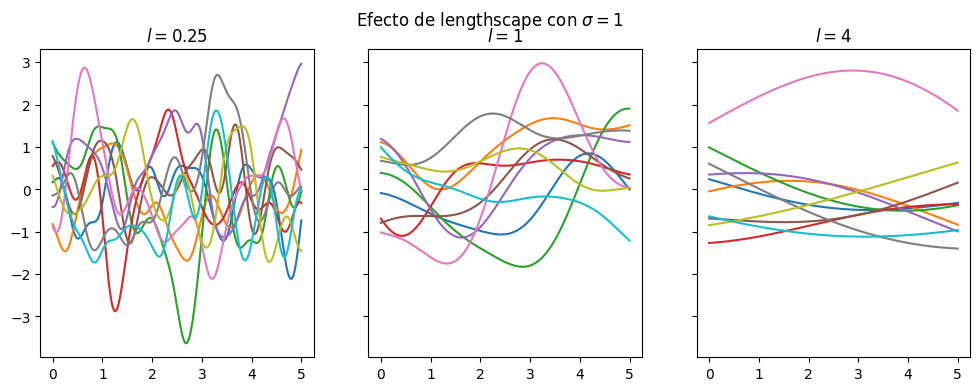

In [6]:
# DIAPOSITIVA 62
x = np.linspace(0,5,1000)
p_1 = simular_GP_RBF(x,1,1,10)
p_4 = simular_GP_RBF(x,1,4,10)
p_25 = simular_GP_RBF(x,1,0.25,10)
#Hago la figura usando plt.subplots. En este caso, hay 3 plots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.suptitle(r'Efecto de lengthscape con $\sigma = 1$')
for i in range(10):
  ax1.plot(x,p_25[i,:], '-')
  ax1.set_title('$l = 0.25$')
  ax2.plot(x,p_1[i,:], '-')
  ax2.set_title('$l = 1$')
  ax3.plot(x,p_4[i,:], '-')
  ax3.set_title('$l = 4$')


## 3. Simular un GP con kernel periódico

En esta sección vamos a definir una función `simular_GP_periodic` que nos permita simular de un GP con kernel periódico. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [7]:

def simular_GP_periodic(t, sigma_sq=1, lengthscale=1, period=1, num_samples=1):
    """
    Simular un GP con kernel periódico.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    sigma_sq: varianza del kernel. Float.
    lengthscale: parámetro de escala del kernel. Float.
    period: Periodo del GP. Float.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t.
    n = len(t)
    # Paso 1: calcula el vector de medias (que es cero por definición.)
    vector_medias = np.zeros(n)
    #Paso 2: Calcula el vector de covarianzas, que es el kernel periódico.
    #(t[:, None] - t[None, :]) genera la matriz $a_{ij} = t_i - t_j$
    matriz_covs = sigma_sq * np.exp(-1/(2*lengthscale**2) * np.sin(np.pi*(t[:, None] - t[None, :])/period)**2)

    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

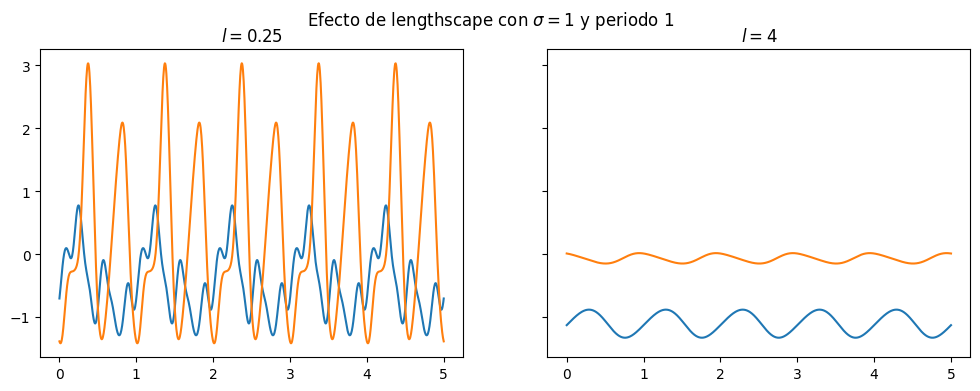

In [8]:
# DIAPOSITIVA 72
x = np.linspace(0,5,1000)
p_4 = simular_GP_periodic(x,1,4,1,2)
p_25 = simular_GP_periodic(x,1,0.25,1,2)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.suptitle(r'Efecto de lengthscape con $\sigma = 1$ y periodo 1')
for i in range(2):
  ax2.plot(x,p_4[i,:], '-')
  ax2.set_title('$l = 4$')
  ax1.plot(x,p_25[i,:], '-')
  ax1.set_title('$l = 0.25$')

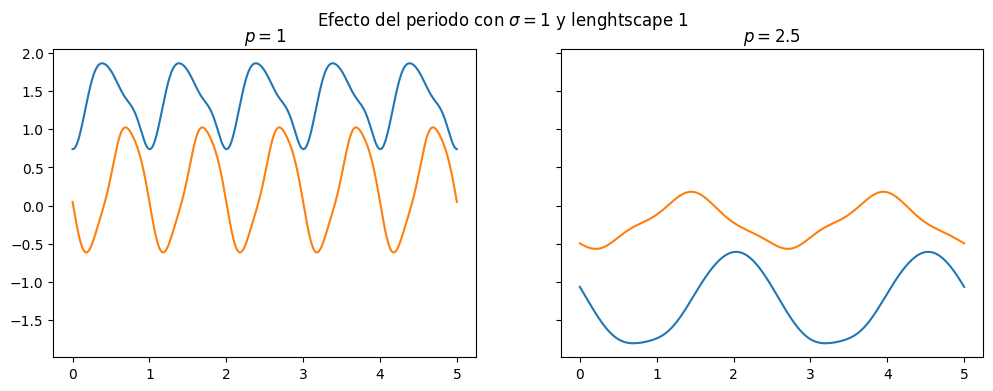

In [9]:
# DIAPOSITIVA 74
x = np.linspace(0,5,1000)
p_1 = simular_GP_periodic(x,1,1,1,2)
p_25 = simular_GP_periodic(x,1,1,2.5,2)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.suptitle(r'Efecto del periodo con $\sigma = 1$ y lenghtscape 1')
for i in range(2):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$p = 1$')
  ax2.plot(x,p_25[i,:], '-')
  ax2.set_title('$p = 2.5$')

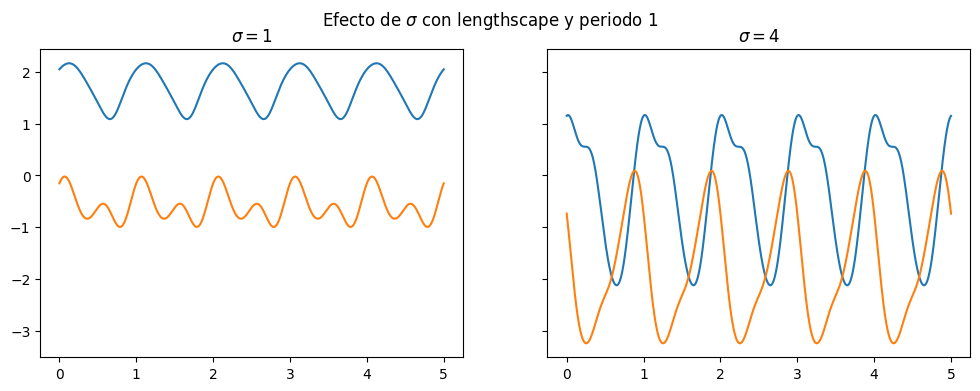

In [10]:
# DIAPOSITIVA 76
x = np.linspace(0,5,1000)
p_1 = simular_GP_periodic(x,1,1,1,2)
p_4 = simular_GP_periodic(x,4,1,1,2)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.suptitle(r'Efecto de $\sigma$ con lengthscape y periodo 1')
for i in range(2):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title(r'$\sigma = 1$')
  ax2.plot(x,p_4[i,:], '-')
  ax2.set_title(r'$\sigma = 4$')

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a definir una función `simular_GP_DPKpoly` que nos permita simular de un GP con kernel DPK. Concretamente, un kernel DPK con funciones base $1$, $t$, $\dots$, $t^m$. Y a continuación la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

In [110]:

def simular_GP_DPKpoly(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK polinómico.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo del polinomio que se suma en el kernel DPK. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t.
    n = len(t)
    # Paso 1: calcula el vector de medias (que es cero por definición.)
    vector_medias = np.zeros(n)
    #Paso 2: Calcula el vector de covarianzas, que es el kernel polinómico.
    #Primero, calculo la matriz auxiliar dada por $M_{ij} = t_i t_j.$
    MatAux = t[:, None]*t[None, :]
    # Ahora utilizo la fórmula de la suma geométrica (evita un bucle for).
    #El caso 1 falla, por eso necesito usar np.where. Añado aun así un pequeño ruido blanco.
    with np.errstate(divide='ignore', invalid='ignore'):
      matriz_covs = (np.where(MatAux == 1, m+1, (MatAux**(m+1)-1)/(MatAux-1))) +  1e-5*np.eye(n)
    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

Hemos utilizado la siguiente fórmula
$$
\sum_{i=0}^{m} x^i = \frac{x^{m+1}-1}{x-1} \quad \forall x \neq 1,
$$
con el fin de poder eliminar el uso del bucle for en el cálculo de la matriz de covarianzas.

Con esta función podemos hacer la gráfica de la diapositiva 89.

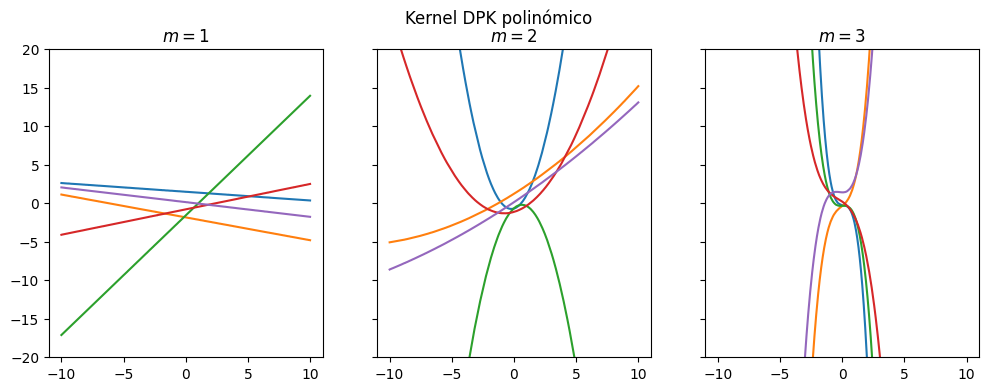

In [111]:
# DIAPOSITIVA 89
x = np.linspace(-10,10,1000)
p_1 = simular_GP_DPKpoly(x,1,5)
p_2 = simular_GP_DPKpoly(x,2,5)
p_3 = simular_GP_DPKpoly(x,3,5)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
ax1.set_ylim(-20,20)
plt.suptitle('Kernel DPK polinómico')
for i in range(5):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$m = 1$')
  ax2.plot(x,p_2[i,:], '-')
  ax2.set_title('$m = 2$')
  ax3.plot(x,p_3[i,:], '-')
  ax3.set_title('$m = 3$')


Este método evita el uso de un bucle for, pero da más errores cuando hay puntos muy cercanos a $x = 1$. Por ello, hacemos esta segunda función.

In [108]:
def simular_GP_DPKpoly2(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK polinómico.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo del polinomio que se suma en el kernel DPK. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t.
    n = len(t)
    # Paso 1: calcula el vector de medias (que es cero por definición.)
    vector_medias = np.zeros(n)
    #Paso 2: Calcula el vector de covarianzas, que es el kernel polinómico.
    #Primero, calculo la matriz auxiliar dada por $M_{ij} = t_i t_j.$
    MatAux = t[:, None]*t[None, :]
    # Ahora utilizo un bucle for para construir la matriz de covarianzas. Le añado un pequeño ruido blanco.
    matriz_covs = 1e-5*np.eye(n)
    for i in range(m+1):
      matriz_covs = matriz_covs + MatAux**i
    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

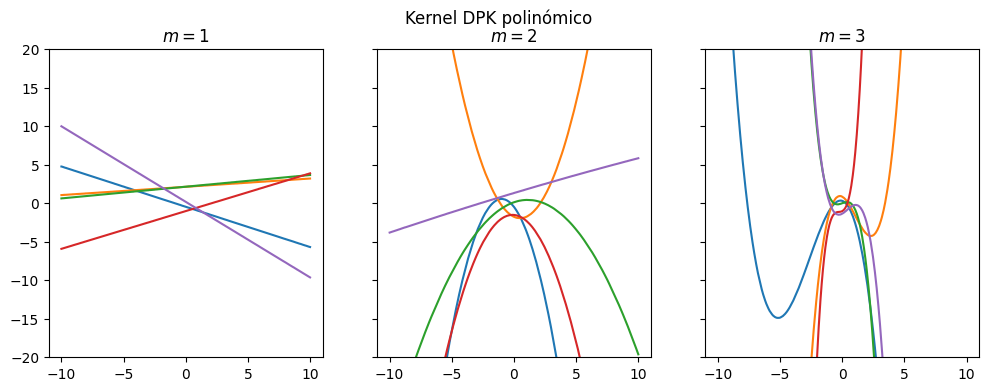

In [109]:
# DIAPOSITIVA 89 (Segunda manera).
x = np.linspace(-10,10,1000)
p_1 = simular_GP_DPKpoly2(x,1,5)
p_2 = simular_GP_DPKpoly2(x,2,5)
p_3 = simular_GP_DPKpoly2(x,3,5)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
ax1.set_ylim(-20,20)
plt.suptitle('Kernel DPK polinómico')
for i in range(5):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$m = 1$')
  ax2.plot(x,p_2[i,:], '-')
  ax2.set_title('$m = 2$')
  ax3.plot(x,p_3[i,:], '-')
  ax3.set_title('$m = 3$')


Podemos hacer una tercera manera. Usaremos que una muestra se da de la forma
$$
X = MY', \text{ con } m_{ij} = f_i(t_j) \text{ e } Y \sim N(0, I_m).
$$

Como queremos devolverlo en forma de vectores filas, ponemos
$$
X' = YN \text{ con } n_{ij} = f_j(t_i) ( \text{ con } N = M').
$$

Esta forma resulta la más estable de las tres que hemos implementado.

In [85]:
def simular_GP_DPKpoly3(t, m=1, num_samples=1):
    """
    Simular un GP con kernel DPK polinómico.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    m: grado máximo del polinomio que se suma en el kernel DPK. Int.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t.
    n = len(t)
    #Paso 1: Calculo la matriz de las funciones 1, x, x^2 ... x^m en los puntos. Shape (m+1,n)
    functions = [lambda x: x**0]
    for i in range(1,m+1):
      functions.append(lambda x : x**(m))
    N = np.vstack([f(t) for f in functions])
    #Paso 2: Calculo una Normal Multivariante de m*m, con num_samples de muestras. (shape(num_samples, m+1))
    Aux = np.random.multivariate_normal(np.zeros(m+1), np.eye(m+1), num_samples)
    #Paso 3: Devuelvo las samples.
    samples = np.matmul(Aux,N)
    return samples

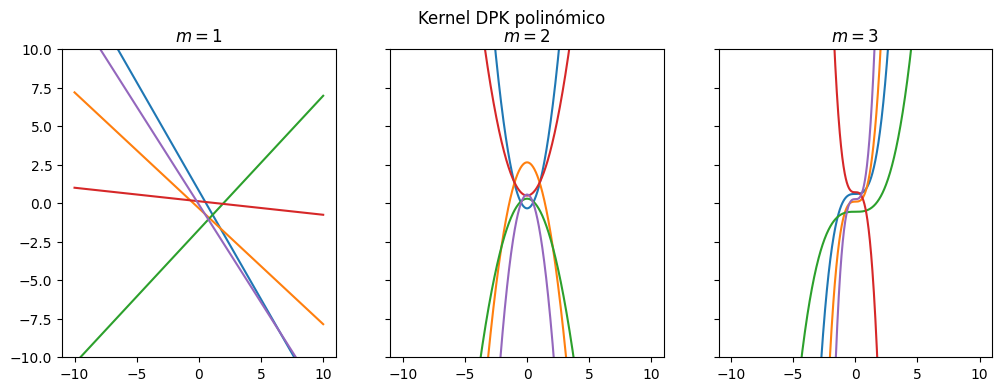

In [86]:
# DIAPOSITIVA 89 (Tercera manera).
x = np.linspace(-10,10,1000)
p_1 = simular_GP_DPKpoly3(x,1,5)
p_2 = simular_GP_DPKpoly3(x,2,5)
p_3 = simular_GP_DPKpoly3(x,3,5)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.suptitle('Kernel DPK polinómico')
ax1.set_ylim(-10,10)
for i in range(5):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$m = 1$')
  ax2.plot(x,p_2[i,:], '-')
  ax2.set_title('$m = 2$')
  ax3.plot(x,p_3[i,:], '-')
  ax3.set_title('$m = 3$')

Probamos que es más estable. Para ello, vamos a pedirle más y más cerca de 1 y 0. Además, haremos 5 veces más plots y dividiremos el intervalo en trozos 100 veces más pequeños. Vemos que tarda menos que las otras dos maneras, a pesar de tener muchos más datos.

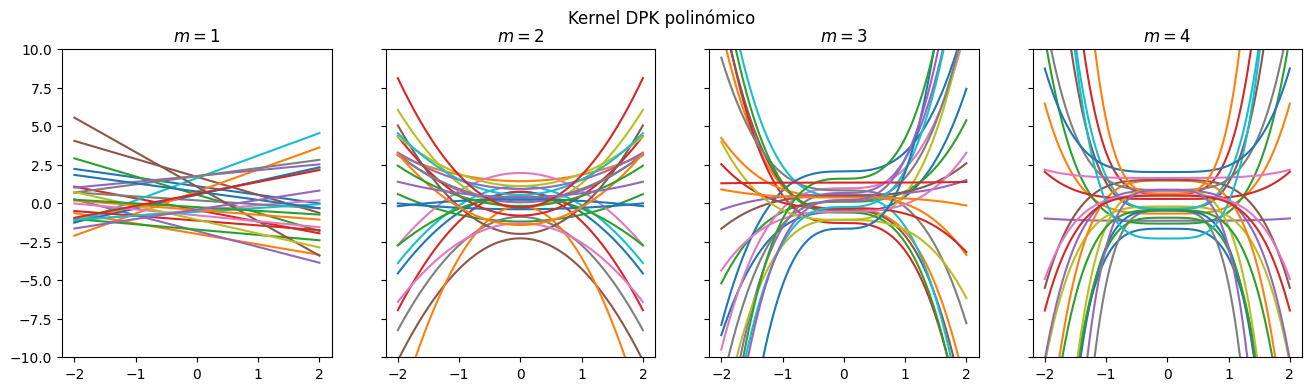

In [88]:
# ESTABILIDAD.
x = np.linspace(-2,2,100000)
p_1 = simular_GP_DPKpoly3(x,1,25)
p_2 = simular_GP_DPKpoly3(x,2,25)
p_3 = simular_GP_DPKpoly3(x,3,25)
p_4 = simular_GP_DPKpoly3(x,4,25)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
plt.suptitle('Kernel DPK polinómico')
ax1.set_ylim(-10,10)
for i in range(25):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$m = 1$')
  ax2.plot(x,p_2[i,:], '-')
  ax2.set_title('$m = 2$')
  ax3.plot(x,p_3[i,:], '-')
  ax3.set_title('$m = 3$')
  ax4.plot(x,p_4[i,:], '-')
  ax4.set_title('$m = 4$')

## 5. Opcional: ¿Cómo hacer que el kernel se pase como parámetro? ¿y la función de medias?

In [21]:
def simular_GP(t, mu, kernel, num_samples=1):
    """
    Simular un GP con kernel DPK polinómico.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    mu: función de medias del GP. Es una función uniparamétrica a los reales.
    kernel: Función de covarianzas (Kernel) del GP. Es una función biparamétrica a los reales.
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t
    n = len(t)
    # Paso 1: calcula el vector de medias, que es evaluar mu en t.
    vector_medias = mu(t)
    #Paso 2: Calcula el vector de covarianzas, que es evaluar el kernel en (t,t).
    matriz_covs = kernel(t[:,np.newaxis], t[np.newaxis,:])
    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

    return samples

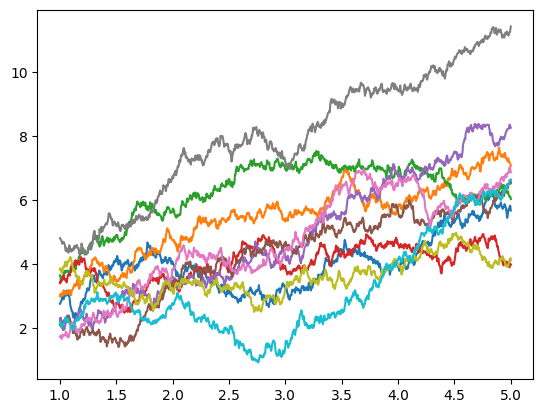

In [22]:
#Vamos a hacer un ejemplo. En este caso, vamos a tomar el kernel del mínimo y medias 2+x
y = np.linspace(1,5,1000)
gp = simular_GP(y, lambda x : 2+x, lambda x,y: np.minimum(x,y), 10)

plt.figure
for i in range(10):
  plt.plot(y,gp[i,:],'-')

Ahora vamos a hacer una función para kernels DPK arbitrarios. Usamos la misma idea que en la tercera función para el kernel polinómico.

Tenemos que en este caso
$$
X' = YN + \mu(t)^T, \text{ con } n_{ij} = f_j(t_i).
$$



In [95]:
def simular_GP_DPK(t, mu, func, num_samples=1):
    """
    Simular un GP con kernel DPK.
    Input:
    t: vector de localizaciones en los que se quiere simular el GP. Numpy array de shape (n,).
    mu: función de medias del GP. Es una función uniparamétrica a los reales.
    func: vector de funciones uniparamétricas que generan el GP. Numpy array de funciones de shape (m,).
    num_samples: número de muestras a generar. Int.

    Output:
    samples: muestras del GP. Numpy array de shape (num_samples, n).

    """
    #Llamo n a la longitud de t y m a la cantidad de funciones que tengo.
    n = len(t)
    m = len(func)
    #Paso 0: Calculo el vector de medias.
    vect_medias = mu(t)
    #Paso 1: Calculo la matriz de las funciones 1, x, x^2 ... x^m en los puntos. Shape (m+1,n)
    N = np.vstack([f(t) for f in func])
    #Paso 2: Calculo una Normal Multivariante de m*m, con num_samples de muestras. (shape(num_samples, m+1))
    Aux = np.random.multivariate_normal(np.zeros(m), np.eye(m), num_samples)
    #Paso 3: Devuelvo las samples.
    samples = np.matmul(Aux,N) + vect_medias.T
    return samples

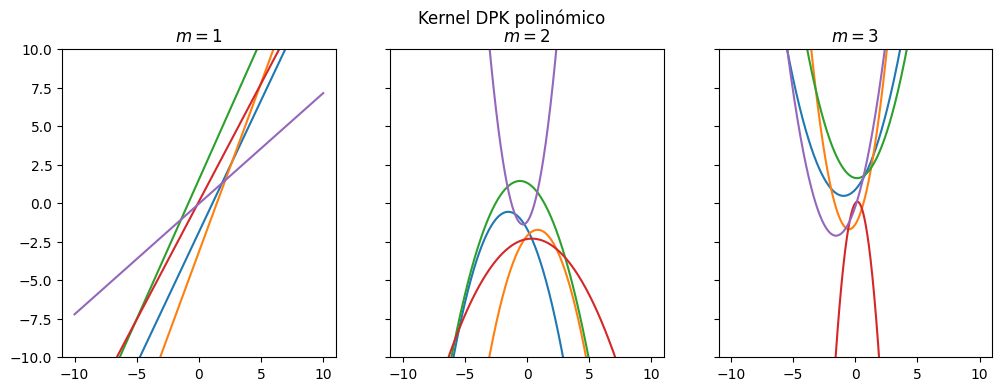

In [99]:
# Test para aplicar la función para DPKs polinómicos, con media x.
x = np.linspace(-10,10,1000)
p_1 = simular_GP_DPK(x,lambda x: x, np.array([lambda x: x**0, lambda x: x**1]),5)
p_2 = simular_GP_DPK(x,lambda x: x, np.array([lambda x: x**0, lambda x: x**1, lambda x: x**2]),5)
p_3 = simular_GP_DPK(x,lambda x: x, np.array([lambda x: x**0, lambda x: x**1, lambda x: x**2, lambda x: x**2]),5)
#Hago la figura usando plt.subplots.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
plt.suptitle('Kernel DPK polinómico')
ax1.set_ylim(-10,10)
for i in range(5):
  ax1.plot(x,p_1[i,:], '-')
  ax1.set_title('$m = 1$')
  ax2.plot(x,p_2[i,:], '-')
  ax2.set_title('$m = 2$')
  ax3.plot(x,p_3[i,:], '-')
  ax3.set_title('$m = 3$')